# Stephenson + COMBAT integration: patient-level representations across methods

This notebook builds sample-level representations of the integrated **Stephenson + COMBAT** COVID-19 dataset (`patpy.datasets.combat_stephenson`) using a panel of complementary methods, then collects every embedding into a single `meta_adata` whose `.X` is the **baseline mean pseudobulk** of log-normalised expression and whose `.obsm` carries the alternatives.

**Representations gathered**

| `meta_adata` slot | method | notes |
|---|---|---|
| `.X` / `obsm["X_pseudobulk_lognorm"]` | mean pseudobulk on log-normalised counts | baseline |
| `obsm["X_pseudobulk_scanvi"]`         | mean pseudobulk on the dataset-shipped scANVI embedding (`X_scANVI_dataset`) | latent-space baseline |
| `obsm["X_composition_clr"]`           | `patpy.tl.CellGroupComposition(apply_clr=True)` | SETA-style cell-type composition |
| `obsm["X_gloscope_py"]`               | `patpy.tl.GloScope_py(use_gpu=…)` MDS embedding | GPU when cuML is available |
| `obsm["X_sampleclr_ssl"]`             | SampleCLR self-supervised (pretrain) | from `lueckenlab/SampleCLR` |
| `obsm["X_sampleclr_ft"]`              | SampleCLR fine-tuned on `severity_idx` | same model, after `fine_tune` |
| `obsm["X_pascient"]`                  | `patpy.tl.PaSCient` patient embedding | trained from scratch |

**Reproducibility model.** Every heavy stage is implemented as a function in `scripts/stephenson_combat/pipeline.py` and as a SLURM-runnable script (`scripts/stephenson_combat/0[1-5]_*.py`). The notebook calls those same functions, but for each stage it first checks whether a cached `obsm_<stage>.npz` file is present; if so it loads, otherwise it computes inline. Long jobs (SampleCLR, PaSCient, GloScope GPU) are usually pre-computed via SLURM with the matching `.sbatch` files in that directory.

**Environment.** Conda env `patpy-stephenson` (see `scripts/stephenson_combat/README.md` for the install commands), `patpy` editable install on branch `stephenson-combat-integration`, `sampleclr` installed from `git+https://github.com/lueckenlab/SampleCLR.git@main`."

In [1]:
# If the env is not yet set up, the cell below installs the two pieces that
# don't ship in PyPI patpy. Run once, then comment out.

# %pip install -U git+https://github.com/lueckenlab/SampleCLR.git@main
# %pip install -e /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy
# %pip install git+https://github.com/genentech/pascient.git@main
# %pip install "cupy-cuda12x" "cuml-cu12"  # only needed for GPU GloScope_py

In [2]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import patpy
import sampleclr

# pull in the shared pipeline helpers
REPO_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy")
sys.path.insert(0, str(REPO_DIR / "scripts" / "stephenson_combat"))
import pipeline as p  # noqa: E402

print("patpy     :", patpy.__version__)
print("sampleclr :", sampleclr.__version__)
print("scanpy    :", sc.__version__)
print("anndata   :", ad.__version__)

np.random.seed(p.SEED)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patpy     : 0.14.0
sampleclr : 0.1.0
scanpy    : 1.12
anndata   : 0.12.10


/localscratch/vladimir.shitov/ipykernel_3874053/612079971.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy    :", sc.__version__)
/localscratch/vladimir.shitov/ipykernel_3874053/612079971.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata   :", ad.__version__)


## 1. Load the integrated COVID-19 dataset

`patpy.datasets.combat_stephenson` returns the harmonised Stephenson + COMBAT cohort plus a `DatasetInfo` that names the donor (`sample_id`) and cell-type (`cell_coarse_aligned`) columns. The released file already ships:

- raw counts in `adata.layers["X_raw_counts"]`,
- a scANVI integration of the two studies in `adata.obsm["X_scANVI_dataset"]`,
- a UMAP of the same in `adata.obsm["X_umap_scANVI_dataset"]`,
- per-sample metadata (severity, outcome, site, etc.) already in `adata.obs`.

We set the default `X_umap` to the scANVI UMAP so `sc.pl.umap` calls without `basis=` work on the dataset's preferred view."

In [3]:
adata, info = p.load_dataset()
adata.obsm["X_umap"] = adata.obsm["X_umap_scANVI_dataset"]  # default basis for sc.pl.umap
print(adata)
print("layers:", list(adata.layers))
print("obsm:  ", list(adata.obsm))
print("sample_key   :", info.sample_key)
print("cell_type_key:", info.cell_type_key)
print("n_samples    :", adata.obs[info.sample_key].nunique())

Reported content length for https://ndownloader.figshare.com/files/64486770 is 0 bytes. The file may be empty.


Downloading:   0%|          | 0.00/15.7G [00:00<?, ?B/s]

Downloading:   0%|          | 344k/15.7G [00:00<1:33:31, 2.80MB/s]

Downloading:   0%|          | 2.99M/15.7G [00:00<16:54, 15.5MB/s] 

Downloading:   0%|          | 12.1M/15.7G [00:00<05:25, 48.1MB/s]

...

Downloading: 100%|█████████▉| 15.7G/15.7G [03:17<00:00, 89.6MB/s]

Downloading: 100%|█████████▉| 15.7G/15.7G [03:17<00:00, 87.7MB/s]

Downloading: 100%|█████████▉| 15.7G/15.7G [03:17<00:00, 87.2MB/s]

Downloading: 100%|██████████| 15.7G/15.7G [03:17<00:00, 79.6MB/s]

AnnData object with n_obs × n_vars = 1399435 × 1856
    obs: 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'split', 'cell_coarse_aligned', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'dataset', 'sample_id', 'Status_encoded', 'leiden'
    uns: 'Site_colors', 'X_scVI_neighbors', 'X_umap_scANVI_dataset', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'cell_coarse_aligned_colors', 'dataset_colors', 'leiden', 'leiden_colors', 'neighbors', 'scANVI_neighbors_dataset', 'severity_ord_colors', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_batch', 'X_scANVI_dataset', 'X_scANVI_sample', 'X_scVI', 'X_scVI_batch',

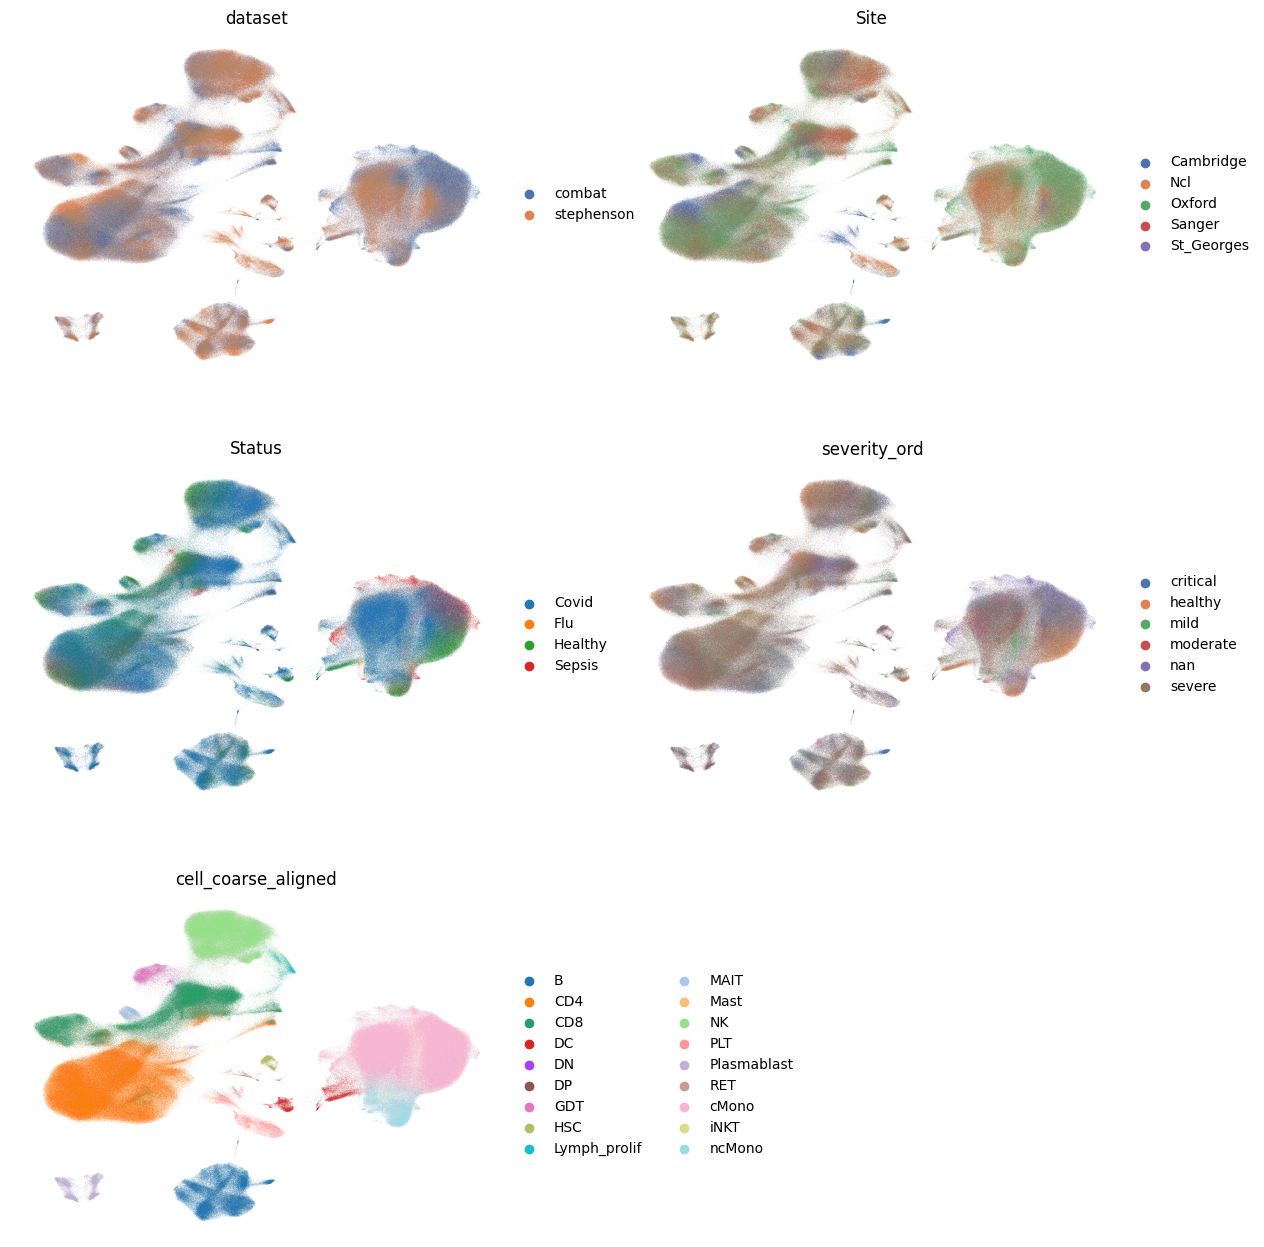

In [4]:
sc.pl.umap(
    adata,
    color=["dataset", "Site", "Status", "severity_ord", "cell_coarse_aligned"],
    frameon=False,
    ncols=2,
)

## 2. Simple preprocessing on raw counts

We normalise the raw counts to 10k UMIs per cell and apply `log1p`. The log-normalised matrix becomes `adata.X` (also kept under `adata.layers["X_log1p"]`); the raw counts move to `adata.layers["counts"]` so PaSCient and other count-based methods can still pick them up by name."

In [5]:
adata = p.preprocess(adata)
print("X is now log-normalised:")
print("  X.max =", float(adata.X.max()), " X.min =", float(adata.X.min()))
print("layers:", list(adata.layers))

X is now log-normalised:


  X.max = 9.158218383789062  X.min = 0.0
layers: ['X_raw_counts', 'counts', 'X_log1p']


## 3. Sample-level metadata and train / val / test split

`patpy.pp.extract_metadata` collapses cell-level `.obs` into one row per donor, keeping the columns that `DatasetInfo` advertises as sample-level. We add a 50 / 25 / 25 random split used downstream by SampleCLR's batch-aware sampler."

In [6]:
metadata = p.build_metadata(adata, info)
print(metadata["split"].value_counts())
metadata.head()

split
train    127
test      62
val       62
Name: count, dtype: int64


,dataset,Site,SARSCoV2PCR,Outcome,TimeSinceOnset,split,Status,severity_ord,severity_idx,outcome_bin,Status_encoded
sample_id,,,,,,,,,,,
S00109-Ja001E-PBCa,combat,Oxford,1,2.0,12.0,test,Covid,severe,3,0.0,0.0
S00112-Ja003E-PBCa,combat,Oxford,1,5.0,12.0,train,Covid,mild,1,0.0,0.0
S00005-Ja005E-PBCa,combat,Oxford,1,2.0,14.0,test,Covid,critical,4,0.0,0.0
S00061-Ja003E-PBCa,combat,Oxford,1,4.0,6.0,val,Covid,severe,3,0.0,0.0
S00056-Ja003E-PBCa,combat,Oxford,1,3.0,23.0,train,Covid,severe,3,0.0,0.0


## 4. Build `meta_adata`

`meta_adata.X` is set to the **mean pseudobulk of the log-normalised counts** — the simplest possible patient-level baseline. The same matrix is also stored in `obsm["X_pseudobulk_lognorm"]` for symmetry with the other representations. The scANVI-pseudobulk (mean of the dataset-shipped integration embedding) and the CLR-transformed cell-type composition vector go straight into `obsm`."

In [7]:
def maybe_compute(stage, compute_fn):
    """Load `obsm_<stage>.npz` if it exists, otherwise compute via `compute_fn`.

    `compute_fn` must return a DataFrame indexed by sample id. The result is
    persisted to `DATA_DIR / obsm_<stage>.npz` for cheap re-runs.
    """
    obsm_path = p.DATA_DIR / f"obsm_{stage}.npz"
    if obsm_path.exists():
        print(f"  [cache] {stage}: {obsm_path.name}")
        return p.load_obsm(stage)
    df = compute_fn()
    p.save_obsm(stage, df)
    return df


pb_lognorm = maybe_compute(
    "pseudobulk_lognorm",
    lambda: p.pseudobulk_mean(adata, info, layer=p.LOGNORM_LAYER),
)
pb_scanvi = maybe_compute(
    "pseudobulk_scanvi",
    lambda: p.pseudobulk_mean(adata, info, layer=p.SCANVI_OBSM),
)
comp_clr = maybe_compute("composition_clr", lambda: p.composition_clr(adata, info))
print("shapes:", pb_lognorm.shape, pb_scanvi.shape, comp_clr.shape)

  [cache] pseudobulk_lognorm: obsm_pseudobulk_lognorm.npz
  [cache] pseudobulk_scanvi: obsm_pseudobulk_scanvi.npz
  [cache] composition_clr: obsm_composition_clr.npz
shapes: (251, 1856) (251, 30) (251, 18)


In [8]:
sample_order = list(metadata.index)
pb_lognorm = pb_lognorm.reindex(sample_order)

meta_adata = ad.AnnData(
    X=pb_lognorm.values.astype(np.float32),
    obs=metadata,
    var=pd.DataFrame(index=adata.var_names),
)
meta_adata.layers["pseudobulk_lognorm"] = meta_adata.X
meta_adata.uns["sample_key"] = info.sample_key
meta_adata.uns["cell_type_key"] = info.cell_type_key

for stage, df in [
    ("pseudobulk_lognorm", pb_lognorm),
    ("pseudobulk_scanvi",  pb_scanvi),
    ("composition_clr",    comp_clr),
]:
    p.attach_obsm(meta_adata, stage, df)

meta_adata

AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded'
    uns: 'sample_key', 'cell_type_key'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr'
    layers: 'pseudobulk_lognorm'

## 5. SampleCLR self-supervised + fine-tuned

`sampleclr.ContrastiveModel` is trained on the scANVI embedding (single batch-corrected latent space across the two cohorts). We first **pretrain** (self-supervised contrastive objective with the batch-aware sampler keyed on `Site`) and snapshot the embeddings, then **fine-tune** the same model with the `severity_idx` classification head and snapshot again. Both stages are heavy on GPU memory; the corresponding sbatch script lives at `scripts/stephenson_combat/02_sampleclr.sbatch`."

In [9]:
# Train SampleCLR inline only if neither cached file exists. When training
# happens here, pipeline.sampleclr_train ALSO persists the best ssl/ft state
# dicts to MODELS_DIR/sampleclr_{ssl,ft}_state.pt for reproducibility.
ssl_path = p.DATA_DIR / "obsm_sampleclr_ssl.npz"
ft_path  = p.DATA_DIR / "obsm_sampleclr_ft.npz"

if ssl_path.exists() and ft_path.exists():
    print("[cache] using saved sampleclr embeddings")
    sclr_ssl = p.load_obsm("sampleclr_ssl")
    sclr_ft  = p.load_obsm("sampleclr_ft")
else:
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sclr_ssl, sclr_ft, stats = p.sampleclr_train(
        adata, info, metadata=metadata, device=device, save_checkpoints=True,
    )
    p.save_obsm("sampleclr_ssl", sclr_ssl)
    p.save_obsm("sampleclr_ft",  sclr_ft)
    print(stats)

for stage, df in [("sampleclr_ssl", sclr_ssl), ("sampleclr_ft", sclr_ft)]:
    p.attach_obsm(meta_adata, stage, df)
print("sampleclr_ssl:", sclr_ssl.shape, "sampleclr_ft:", sclr_ft.shape)
print("checkpoints:", p.SAMPLECLR_SSL_CKPT.exists(), p.SAMPLECLR_FT_CKPT.exists())

[cache] using saved sampleclr embeddings
sampleclr_ssl: (251, 128) sampleclr_ft: (251, 128)
checkpoints: True True


## 6. GloScope_py (GPU when available)

`patpy.tl.GloScope_py` computes a symmetric KL distance between donors directly from a continuous embedding. With `use_gpu=True` it uses RAPIDS `cuML.NearestNeighbors`; the fallback is `pynndescent` on CPU. We feed it the scANVI embedding so the resulting distances are comparable across the two cohorts. The MDS embedding of the distance matrix becomes the `obsm` we store."

In [10]:
def _gloscope_compute():
    try:
        import cuml  # noqa: F401
        import cupy  # noqa: F401
        import torch
        use_gpu = torch.cuda.is_available()
    except Exception as e:
        print(f"  cuML/cupy unavailable ({type(e).__name__}); falling back to CPU")
        use_gpu = False
    df, distances = p.gloscope_py(adata, info, use_gpu=use_gpu)
    np.savez(p.DATA_DIR / "gloscope_py_distances.npz",
             distances=distances, samples=np.asarray(df.index))
    return df

gloscope_df = maybe_compute("gloscope_py", _gloscope_compute)
p.attach_obsm(meta_adata, "gloscope_py", gloscope_df)
print("gloscope_py:", gloscope_df.shape)

  [cache] gloscope_py: obsm_gloscope_py.npz
gloscope_py: (251, 30)


## 7. PaSCient (supervised patient encoder)

PaSCient is trained from scratch on log-normalised counts with `severity_idx` as the donor-level classification target. We pass `normalize=False` because we already log-normalised `adata.X`; the hierarchical encoder yields a fixed-size patient embedding."

In [11]:
def _pascient_compute():
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return p.pascient_train(adata, info, device=device, save_checkpoints=True)

pascient_df = maybe_compute("pascient", _pascient_compute)
p.attach_obsm(meta_adata, "pascient", pascient_df)
print("pascient:", pascient_df.shape)
print("checkpoint:", p.PASCIENT_CKPT.exists())

  [cache] pascient: obsm_pascient.npz
pascient: (251, 512)
checkpoint: True


## 8. Final `meta_adata` and quick visual sanity-check

`meta_adata` now carries all seven representations. We persist it to `data/stephenson_combat/meta_adata.h5ad`, then take UMAPs over the supervised SampleCLR fine-tuned and the unsupervised GloScope representations as a sanity-check that severity gradients fall out where we'd expect."

In [12]:
# Categorical order + colour maps for plotting (matches the original notebook).
if "Status" in meta_adata.obs and hasattr(meta_adata.obs["Status"], "cat"):
    meta_adata.obs["Status"] = meta_adata.obs["Status"].cat.reorder_categories(
        ["Healthy", "Covid", "Flu", "Sepsis"], ordered=False,
    )
    meta_adata.uns["Status_colors"] = ["lightblue", "salmon", "orange", "darkred"]

if "severity_ord" in meta_adata.obs and hasattr(meta_adata.obs["severity_ord"], "cat"):
    meta_adata.obs["severity_ord"] = meta_adata.obs["severity_ord"].cat.reorder_categories(
        ["nan", "healthy", "mild", "moderate", "severe", "critical"], ordered=True,
    )
    meta_adata.uns["severity_ord_colors"] = [
        "lightgray", "lightblue", "royalblue", "orange", "salmon", "darkred",
    ]
meta_adata

AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded'
    uns: 'sample_key', 'cell_type_key', 'Status_colors', 'severity_ord_colors'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr', 'X_sampleclr_ssl', 'X_sampleclr_ft', 'X_gloscope_py', 'X_pascient'
    layers: 'pseudobulk_lognorm'

In [13]:
# patpy benchmarking wants `meta_adata.obsm[<rep>]` (the embedding),
# `obsm[<rep>_distances]` (pairwise distances) and `<rep>_neighbors` neighbor
# graphs. `setup_benchmarking` populates all three plus per-rep UMAPs into
# `obsm["X_umap_<rep>"]`. For GloScope we feed in the original symmetric-KL
# distance matrix saved by stage 04 instead of recomputing Euclidean.
gloscope_dists_path = p.DATA_DIR / "gloscope_py_distances.npz"
representations = p.setup_benchmarking(
    meta_adata,
    gloscope_distances_path=gloscope_dists_path if gloscope_dists_path.exists() else None,
)
print("representations:", representations)

  [ok] pseudobulk_lognorm: distances (251, 251), neighbors+UMAP done


  [ok] pseudobulk_scanvi: distances (251, 251), neighbors+UMAP done


  [ok] composition_clr: distances (251, 251), neighbors+UMAP done


  [ok] gloscope_py: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ssl: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ft: distances (251, 251), neighbors+UMAP done


  [ok] pascient: distances (251, 251), neighbors+UMAP done


representations: ['pseudobulk_lognorm', 'pseudobulk_scanvi', 'composition_clr', 'gloscope_py', 'sampleclr_ssl', 'sampleclr_ft', 'pascient']


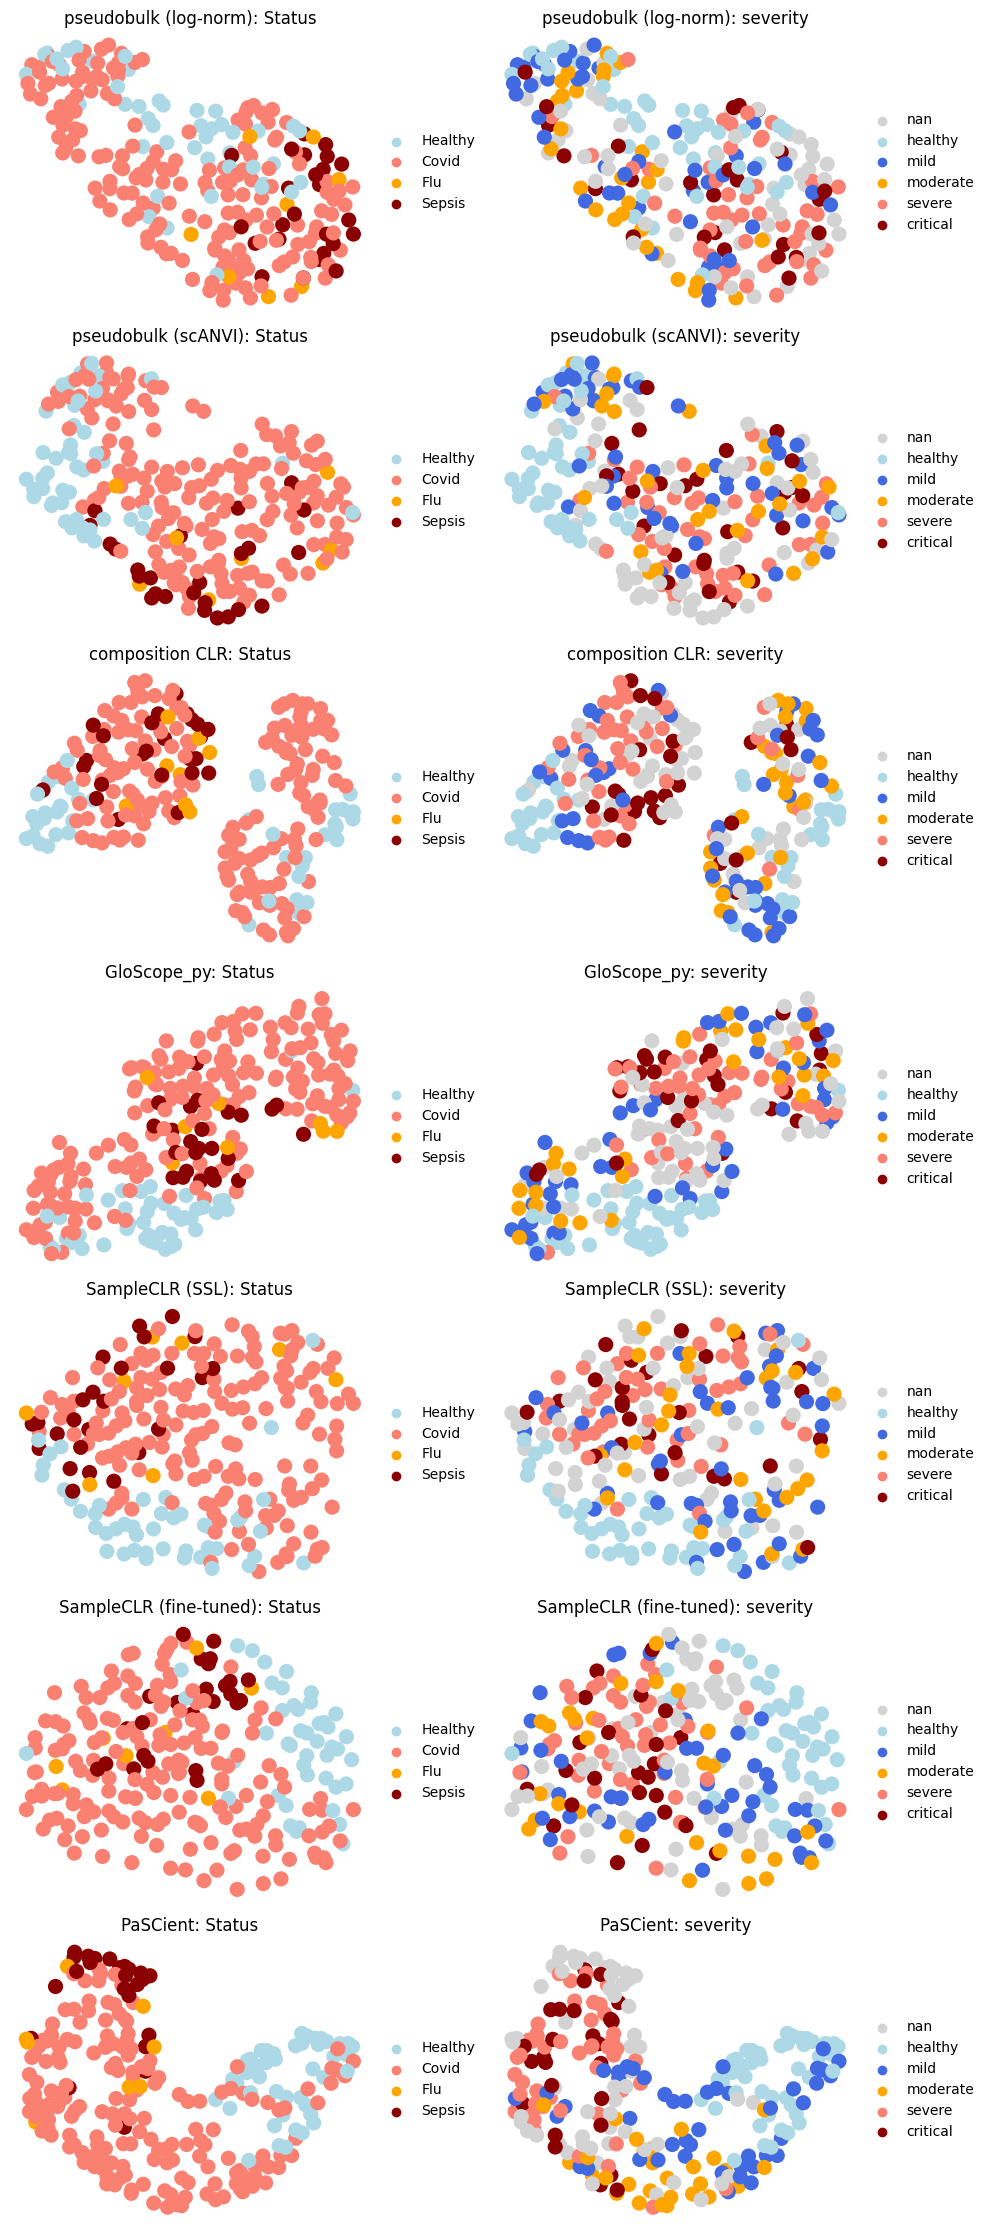

array([[-6.4101305 ,  8.832444  ],
       [-3.0582385 , 10.221959  ],
       [-3.635923  , 10.805858  ],
       [-5.7059627 ,  9.680307  ],
       [-2.9526653 ,  9.7135515 ],
       [-2.6589158 , 10.485673  ],
       [ 1.4779593 , 11.2107115 ],
       [ 1.5355328 , 10.9791155 ],
       [-3.1780145 ,  9.317517  ],
       [-2.8289666 ,  9.863338  ],
       [-5.505408  ,  9.03998   ],
       [-4.300665  , 15.1014805 ],
       [ 1.2345755 , 10.8342    ],
       [-5.4858913 , 11.051603  ],
       [-4.1501236 , 14.630279  ],
       [ 2.183947  , 11.5271225 ],
       [-4.108429  , 14.486877  ],
       [-3.4992707 , 14.720487  ],
       [-3.0594125 , 13.296176  ],
       [ 0.29221115, 10.006495  ],
       [-3.9510927 , 12.574963  ],
       [ 1.0228229 , 10.258432  ],
       [-5.2701063 ,  9.409568  ],
       [-3.0689316 , 10.44849   ],
       [-3.427591  , 14.013471  ],
       [-4.7765718 , 12.488737  ],
       [-3.3437493 , 13.853669  ],
       [-4.7934213 ,  9.040416  ],
       [ 2.929703  ,

In [14]:
PANELS = [
    ("pseudobulk_lognorm", "pseudobulk (log-norm)"),
    ("pseudobulk_scanvi",  "pseudobulk (scANVI)"),
    ("composition_clr",    "composition CLR"),
    ("gloscope_py",        "GloScope_py"),
    ("sampleclr_ssl",      "SampleCLR (SSL)"),
    ("sampleclr_ft",       "SampleCLR (fine-tuned)"),
    ("pascient",           "PaSCient"),
]

fig, axes = plt.subplots(len(PANELS), 2, figsize=(10, 3.2 * len(PANELS)), squeeze=False)
for row, (rep, title) in enumerate(PANELS):
    umap_key = f"X_umap_{rep}"
    if umap_key not in meta_adata.obsm:
        for ax in axes[row]:
            ax.set_visible(False)
        continue
    meta_adata.obsm["X_umap"] = meta_adata.obsm[umap_key]
    sc.pl.umap(meta_adata, color="Status",       ax=axes[row, 0], show=False, frameon=False, title=f"{title}: Status")
    sc.pl.umap(meta_adata, color="severity_ord", ax=axes[row, 1], show=False, frameon=False, title=f"{title}: severity")
plt.tight_layout()
plt.show()
meta_adata.obsm.pop("X_umap", None)  # leave only the per-rep UMAPs on disk

## 9. Benchmark: KNN scores and trajectory preservation

We score each representation along three axes using `patpy.tl.evaluation.knn_prediction_score` (wrapped by `pipeline.benchmark_knn`):

- **Relevant** (clinical information retention): KNN prediction of `severity_idx` (ranking, integer-coded severity), `Status` (classification), `outcome_bin` (classification).
- **Technical** (batch mixing): KNN prediction of `Site` and `dataset`. Scores are inverted (`1 - score`) so higher = better batch mixing.
- **Contextual**: KNN regression of `TimeSinceOnset`.

A second benchmark uses `patpy.tl.evaluation.trajectory_correlation` to compute a diffusion pseudotime per representation (rooted on a Healthy donor) and Spearman-correlates it with `severity_idx`. Both tables are persisted alongside the final meta_adata.

Note that the helper does an in-place `prepare_benchmark_columns` cast — `TimeSinceOnset`, `severity_idx`, `outcome_bin`, `Status_encoded` are all coerced to `float64` because sklearn KNeighborsRegressor cannot multiply strings or pandas `Int64`."

In [15]:
knn_df = p.benchmark_knn(meta_adata)
knn_df.to_csv(p.BENCHMARK_KNN_CSV, index=False)
knn_pivot = knn_df.pivot_table(
    index="representation", columns=["covariate_type", "covariate"], values="score"
).round(3)
knn_pivot

covariate_type         contextual relevant                          technical  \
covariate          TimeSinceOnset   Status outcome_bin severity_idx      Site   
representation                                                                  
composition_clr             0.226    0.447       0.000        0.341     0.372   
gloscope_py                 0.448    0.448       0.276        0.573     0.517   
pascient                    0.149    0.460       0.000        0.522     0.515   
pseudobulk_lognorm          0.365    0.288       0.001        0.417     0.498   
pseudobulk_scanvi           0.382    0.355       0.006        0.415     0.659   
sampleclr_ft                0.438    0.454       0.059        0.603     0.672   
sampleclr_ssl               0.454    0.380       0.135        0.513     0.672   

covariate_type              
covariate          dataset  
representation              
composition_clr      0.000  
gloscope_py          0.056  
pascient             0.048  
pseudobulk_lognorm   0.032  
pseudobulk_scanvi    0.235  
sampleclr_ft         0.249  
sampleclr_ssl        0.265

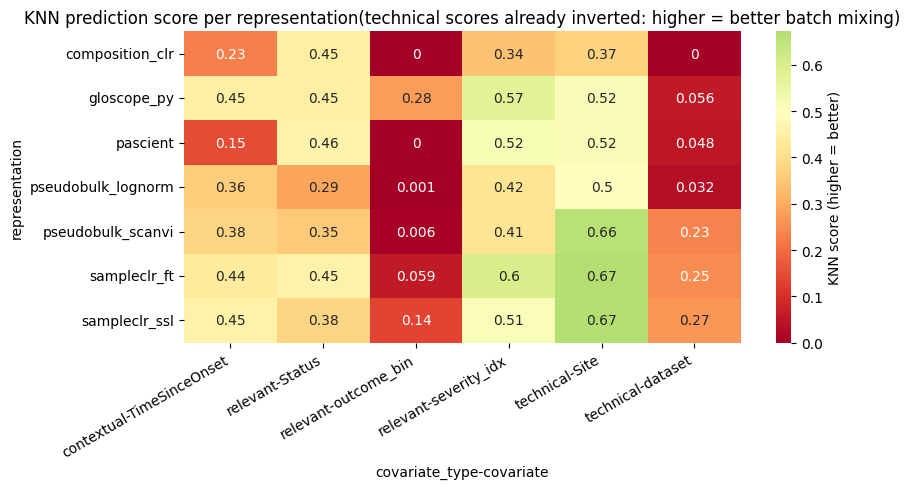

In [16]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(knn_pivot, annot=True, cmap="RdYlGn", center=0.5, ax=ax, cbar_kws={"label": "KNN score (higher = better)"})
ax.set_title("KNN prediction score per representation\
(technical scores already inverted: higher = better batch mixing)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

  trajectory root: H00067-Ha001E-PBGa (Status=Healthy)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
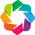

Computing diffmap for pseudobulk_lognorm
Computing diffmap for pseudobulk_scanvi
Computing diffmap for composition_clr
Computing diffmap for gloscope_py
Computing diffmap for sampleclr_ssl
Computing diffmap for sampleclr_ft
Computing diffmap for pascient


,correlation
sampleclr_ft,0.306559
pascient,0.201859
gloscope_py,0.180465
sampleclr_ssl,0.134062
pseudobulk_scanvi,0.129826
pseudobulk_lognorm,-0.073636
composition_clr,-0.100575


In [17]:
traj_df = p.benchmark_trajectory(meta_adata, trajectory_variable="severity_idx")
traj_df.to_csv(p.BENCHMARK_TRAJECTORY_CSV)
traj_df

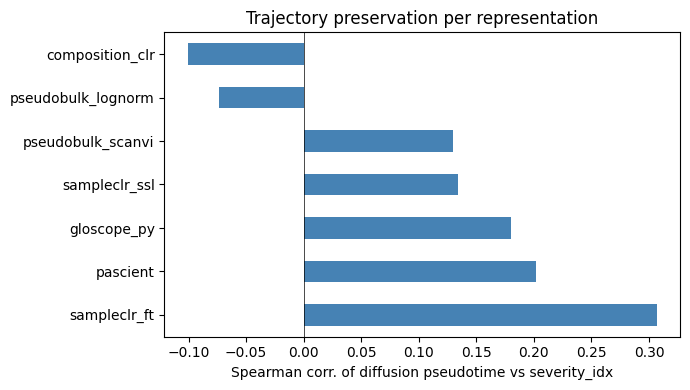

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
traj_df.plot.barh(y="correlation", ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Spearman corr. of diffusion pseudotime vs severity_idx")
ax.set_title("Trajectory preservation per representation")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## 10. Persist the final `meta_adata`

Save everything (every `obsm[<rep>]`, every `obsm[<rep>_distances]`, every per-rep neighbor graph + UMAP, plus the benchmark tables) to a readably-named h5ad. Model checkpoints are already on disk under `data/.../models/`:

- `models/sampleclr_ssl_state.pt`
- `models/sampleclr_ft_state.pt`
- `models/pascient_state.pt`

together with `models/sampleclr_config.json` and `models/pascient_config.json` describing the hyperparameters used."

In [19]:
meta_adata.write_h5ad(p.META_ADATA_FINAL)
print("final meta_adata:", p.META_ADATA_FINAL)
print("  obsm keys :", sorted(meta_adata.obsm.keys()))
print("  uns reps  :", meta_adata.uns.get("sample_representations"))
print("  benchmarks:", p.BENCHMARK_KNN_CSV.name, p.BENCHMARK_TRAJECTORY_CSV.name)
print("  models    :", *[c.name for c in [p.SAMPLECLR_SSL_CKPT, p.SAMPLECLR_FT_CKPT, p.PASCIENT_CKPT]])

final meta_adata: /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat/stephenson_combat_meta_adata.h5ad
  obsm keys : ['X_composition_clr', 'X_composition_clr_diffmap', 'X_diffmap', 'X_gloscope_py', 'X_gloscope_py_diffmap', 'X_pascient', 'X_pascient_diffmap', 'X_pseudobulk_lognorm', 'X_pseudobulk_lognorm_diffmap', 'X_pseudobulk_scanvi', 'X_pseudobulk_scanvi_diffmap', 'X_sampleclr_ft', 'X_sampleclr_ft_diffmap', 'X_sampleclr_ssl', 'X_sampleclr_ssl_diffmap', 'X_umap_composition_clr', 'X_umap_gloscope_py', 'X_umap_pascient', 'X_umap_pseudobulk_lognorm', 'X_umap_pseudobulk_scanvi', 'X_umap_sampleclr_ft', 'X_umap_sampleclr_ssl', 'composition_clr', 'composition_clr_distances', 'gloscope_py', 'gloscope_py_distances', 'pascient', 'pascient_distances', 'pseudobulk_lognorm', 'pseudobulk_lognorm_distances', 'pseudobulk_scanvi', 'pseudobulk_scanvi_distances', 'sampleclr_ft', 'sampleclr_ft_distances', 'sampleclr_ssl', 'sampleclr_ssl_distances']
  uns reps 